In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, f_regression 

**Reading the file**

In [3]:
df = pd.read_csv('data/ai_job_market.csv')
print(df.head())


   job_id                  job_title company_size company_industry    country  \
0       1                AI Engineer      Startup           Retail     Canada   
1       2  Machine Learning Engineer          MNC       Technology  Australia   
2       3  Machine Learning Engineer          MNC       Technology    Germany   
3       4           Business Analyst      Startup       Healthcare    Germany   
4       5             Data Scientist          MNC       Healthcare    Germany   

  remote_type experience_level  years_experience education_level  \
0      Remote           Senior                 2          Master   
1      Hybrid              Mid                 0        Bachelor   
2      Onsite              Mid                14          Master   
3      Remote              Mid                 9          Master   
4      Hybrid              Mid                 5          Master   

   skills_python  skills_sql  skills_ml  skills_deep_learning  skills_cloud  \
0              0         

In [4]:
df.columns

Index(['job_id', 'job_title', 'company_size', 'company_industry', 'country',
       'remote_type', 'experience_level', 'years_experience',
       'education_level', 'skills_python', 'skills_sql', 'skills_ml',
       'skills_deep_learning', 'skills_cloud', 'salary', 'job_posting_month',
       'job_posting_year', 'hiring_urgency', 'job_openings'],
      dtype='str')

**cleaning the data**

In [5]:
df=df.drop('job_id',axis=1)
df.head()


,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2


**Shape of the data**

In [6]:
df.shape

(10345, 18)

**Checking the null values**

In [7]:
df.isna().sum()

job_title               0
company_size            0
company_industry        0
country                 0
remote_type             0
experience_level        0
years_experience        0
education_level         0
skills_python           0
skills_sql              0
skills_ml               0
skills_deep_learning    0
skills_cloud            0
salary                  0
job_posting_month       0
job_posting_year        0
hiring_urgency          0
job_openings            0
dtype: int64

**As we can observe there is no null values in any features in the given dataset**

In [8]:
df.duplicated().sum()

np.int64(0)

**Not a single duplicate datas in the dataset**

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   job_title             10345 non-null  str  
 1   company_size          10345 non-null  str  
 2   company_industry      10345 non-null  str  
 3   country               10345 non-null  str  
 4   remote_type           10345 non-null  str  
 5   experience_level      10345 non-null  str  
 6   years_experience      10345 non-null  int64
 7   education_level       10345 non-null  str  
 8   skills_python         10345 non-null  int64
 9   skills_sql            10345 non-null  int64
 10  skills_ml             10345 non-null  int64
 11  skills_deep_learning  10345 non-null  int64
 12  skills_cloud          10345 non-null  int64
 13  salary                10345 non-null  int64
 14  job_posting_month     10345 non-null  int64
 15  job_posting_year      10345 non-null  int64
 16  hiring_urgency 

**checking the number of unique datas in each features**

In [10]:
df.nunique()

job_title                  6
company_size               4
company_industry           6
country                    7
remote_type                3
experience_level           3
years_experience          15
education_level            3
skills_python              2
skills_sql                 2
skills_ml                  2
skills_deep_learning       2
skills_cloud               2
salary                  9901
job_posting_month         12
job_posting_year           7
hiring_urgency             3
job_openings               9
dtype: int64

**Studying the statistice of the features**

In [11]:
df.describe()

,years_experience,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,job_openings
count,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.00000,10345.000000,10345.000000,10345.00000
mean,6.950507,0.493088,0.503045,0.507878,0.498018,0.511455,113438.22726,6.502465,2023.000387,5.00406
std,4.320054,0.499976,0.500015,0.499962,0.500020,0.499893,31389.20106,3.473441,1.996856,2.58382
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45083.00000,1.000000,2020.000000,1.00000
25%,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,89715.00000,4.000000,2021.000000,3.00000
50%,7.000000,0.000000,1.000000,1.000000,0.000000,1.000000,113082.00000,6.000000,2023.000000,5.00000
75%,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,134894.00000,10.000000,2025.000000,7.00000
max,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000,204143.00000,12.000000,2026.000000,9.00000


**Visualizing the frequency of salary**

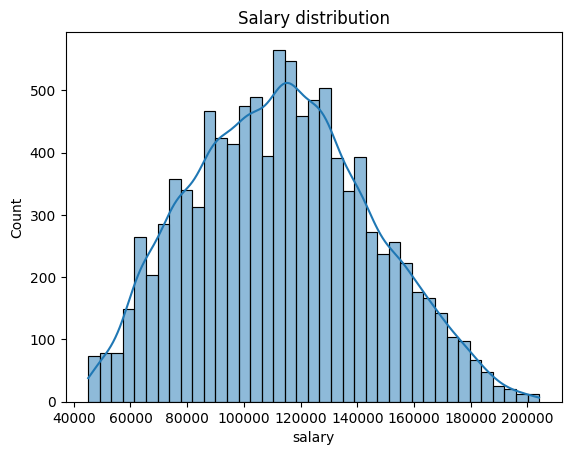

In [12]:
sns.histplot(df['salary'],kde=True)
plt.title('Salary distribution')
plt.show()

In [13]:
categorical_features = [feature for feature in df.columns if df[feature].dtype!=int]
numerical_features = [feature for feature in df.columns if df[feature].dtype==int]  
print(f'The categorical features are: {categorical_features}')
print(f'The numerical features are: {numerical_features}')

The categorical features are: ['job_title', 'company_size', 'company_industry', 'country', 'remote_type', 'experience_level', 'education_level', 'hiring_urgency']
The numerical features are: ['years_experience', 'skills_python', 'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud', 'salary', 'job_posting_month', 'job_posting_year', 'job_openings']


**visualizing the salary based on different categorical features**

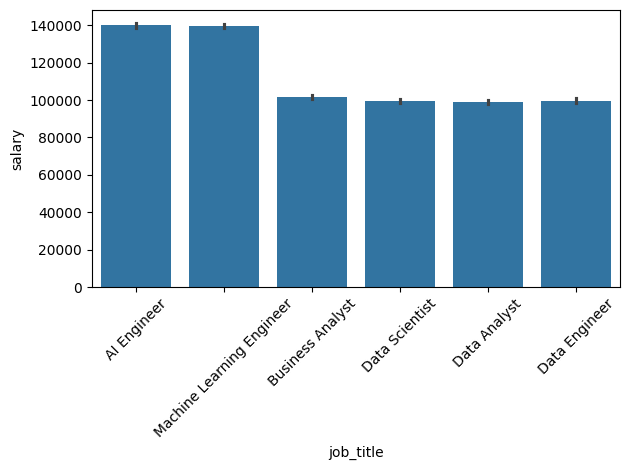

In [17]:
sns.barplot(x='job_title',y='salary',data = df)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

**Insights**

Among the roles analyzed, AI Engineers and Machine Learning Engineers command the highest salaries, averaging around $140,000 USD. In contrast, Business Analysts, Data Scientists, Data Analysts, and Data Engineers earn comparatively less, with salaries approximately $40,000 lower — highlighting a clear premium placed on advanced AI and ML expertise in today's job market.

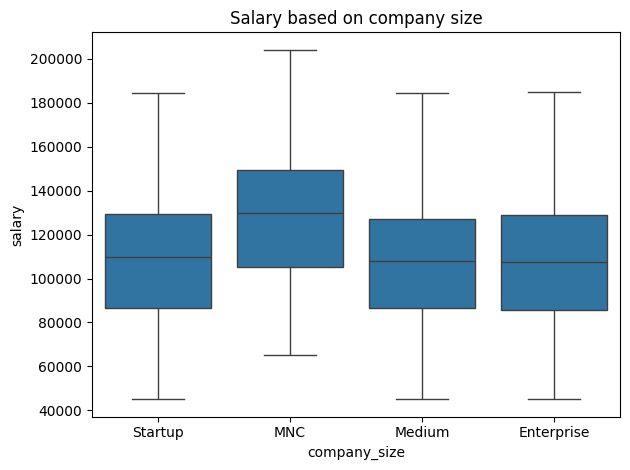

In [19]:
sns.boxplot(x='company_size',y='salary',data = df)
plt.title('Salary based on company size')
plt.tight_layout()
plt.show()

**Insight**

Multinational Corporations (MNCs) offer significantly higher compensation for AI and Data roles compared to Startups, Medium-sized, and Enterprise-level companies — reflecting their greater resources, global demand for talent, and willingness to invest in top-tier professionals.

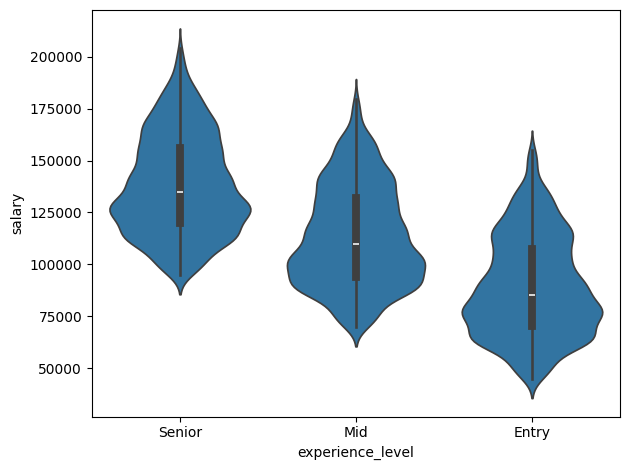

In [20]:
sns.violinplot(x='experience_level',y='salary',data=df)
plt.tight_layout()
plt.show()

**Insights**
  
As anticipated, Senior-level professionals command significantly higher salaries compared to their Mid-level and Entry-level counterparts — reflecting the value placed on years of experience, domain expertise, and the greater responsibilities that come with seniority.

**Checking the correlation between salary and other numerical variables**

In [31]:
corr = df[numerical_features].corr()['salary'].drop('salary').sort_values(ascending=False)  #as salary is the target variable we are dropping it while checking the correlation
corr

skills_deep_learning    0.242504
skills_ml               0.232621
skills_cloud            0.153725
skills_python           0.009536
job_openings            0.005715
job_posting_year        0.003028
skills_sql             -0.003473
years_experience       -0.013266
job_posting_month      -0.013555
Name: salary, dtype: float64

**Plotting the correlation between salary and numeric features**

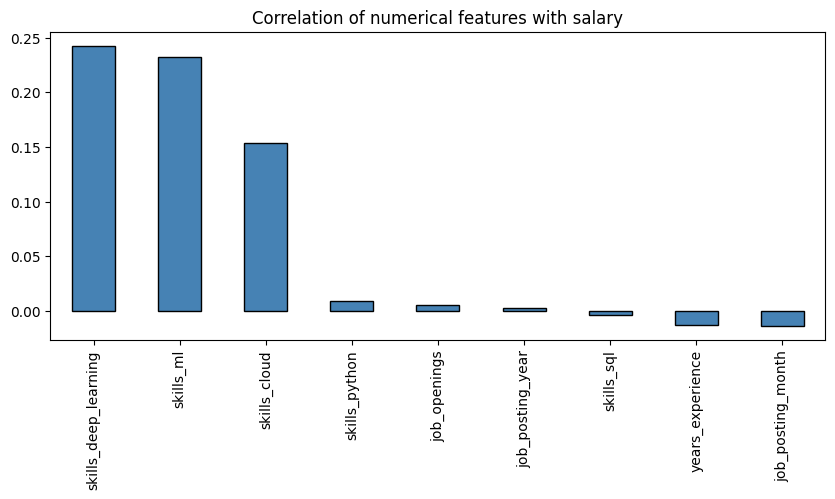

In [32]:
corr.plot(kind='bar',figsize=(10, 4), color='steelblue', edgecolor='black')
plt.title('Correlation of numerical features with salary')
plt.show()

In [23]:
skills_col = ['skills_python', 'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud']
cor_cols = skills_col + ['job_openings']
df[cor_cols].corr()

,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,job_openings
skills_python,1.000000,-0.004266,-0.001813,-0.005952,0.014725,-0.005591
skills_sql,-0.004266,1.000000,0.008122,0.007081,0.004018,0.003133
skills_ml,-0.001813,0.008122,1.000000,0.007120,0.000316,0.012697
skills_deep_learning,-0.005952,0.007081,0.007120,1.000000,-0.010835,0.022604
skills_cloud,0.014725,0.004018,0.000316,-0.010835,1.000000,0.008946
job_openings,-0.005591,0.003133,0.012697,0.022604,0.008946,1.000000
